In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm
from scipy.interpolate import griddata
import scipy
import os
import re


Todo
* Yield curve with different types of assets (Sofr, Bonds, etc.)
* Same analysis but with more historical data: implied volatility VS actual volatility
* Interpolation in 1D
* More advanced interpolation 2D moneyness & term VS ...
* use unsupervized ML algorithms to remove extreme points

```
Options have greatest time value when strike is similar to spot (i.e. ATM)
An ATM option has the greatest time value (the amount the option price is above the
intrinsic value). This can be seen in the same example by looking at an out-the-money
(OTM) call option of strike €60 (an OTM option has strike far away from spot and zero
intrinsic value). This OTM €60 call option would be worth zero, as the stock in this example
cannot rise above €60.
```

Try this empirically

## Data preparation

In [99]:
# Average of the last 30 days of annualized sofr rates
risk_free_rate = 3.64516 / 100.0

# Today
today = pd.Timestamp(year=2026, month=4, day=23, tz="UTC")

# As of the time the data was downloaded
price = 372.825 # 373.72

### Option Data

In [100]:
ticker_str = "TSLA"
available_data = filter(lambda x: ticker_str in x, os.listdir("data"))
dataframes = {}
for filename in available_data:
    dates = re.search("(\d{4})-(\d{2})-(\d{2})", filename)
    if not dates:
        continue
    year, month, day = tuple(int(el) for el in dates.groups())
    contract_type = "call" if "calls" in filename else "put"
    dataframes[pd.Timestamp(year=year, month=month, day=day, tz="UTC")] = (contract_type, pd.read_csv(f"./data/{filename}"))

In [101]:
cols = ["strike", "bid", "ask", "last_price", "yahoo_implied_vol", "type", "last_trade_date", "maturity"]
data = pd.DataFrame(columns=cols)

for maturity, (option_type, df) in dataframes.items():
    extract = df[["strike", "bid", "ask", "impliedVolatility", "lastTradeDate", "lastPrice"]].copy()
    extract["type"] = option_type
    extract["maturity"] = maturity
    extract = extract.rename({"lastPrice": "last_price", "lastTradeDate": "last_trade_date", "impliedVolatility": "yahoo_implied_vol"}, axis="columns")
    extract["last_trade_date"] = pd.to_datetime(extract["last_trade_date"])
    data = pd.concat([data, extract[cols]], axis=0, ignore_index=True)

data = data[ data["last_trade_date"] >= today - pd.DateOffset(days=1)]
data["time_to_maturity"] = (data["maturity"] - today).dt.days / 360
data["moneyness"] = data["strike"] / price
data["price"] = 0.5*(data["bid"]+data["ask"])

data_put = data[data["type"] == "put"].copy()
data_call = data[data["type"] == "call"].copy()

/tmp/ipykernel_10095/1949616465.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, extract[cols]], axis=0, ignore_index=True)


In [102]:
data.head()

,strike,bid,ask,last_price,yahoo_implied_vol,type,last_trade_date,maturity,time_to_maturity,moneyness,price
0,5.0,366.40,372.85,370.29,1.805665,call,2026-04-23 18:12:12+00:00,2028-01-21 00:00:00+00:00,1.772222,0.013411,369.625
14,100.0,282.10,287.00,280.50,0.830202,call,2026-04-23 14:27:22+00:00,2028-01-21 00:00:00+00:00,1.772222,0.268222,284.550
19,150.0,241.75,244.10,245.00,0.722659,call,2026-04-23 17:02:36+00:00,2028-01-21 00:00:00+00:00,1.772222,0.402334,242.925
24,190.0,210.30,212.85,213.28,0.661228,call,2026-04-23 18:40:30+00:00,2028-01-21 00:00:00+00:00,1.772222,0.509622,211.575
26,200.0,203.15,206.25,211.50,0.654606,call,2026-04-23 15:56:48+00:00,2028-01-21 00:00:00+00:00,1.772222,0.536445,204.700


### Yield Curve

## Yield curve

## Implied volatility surface

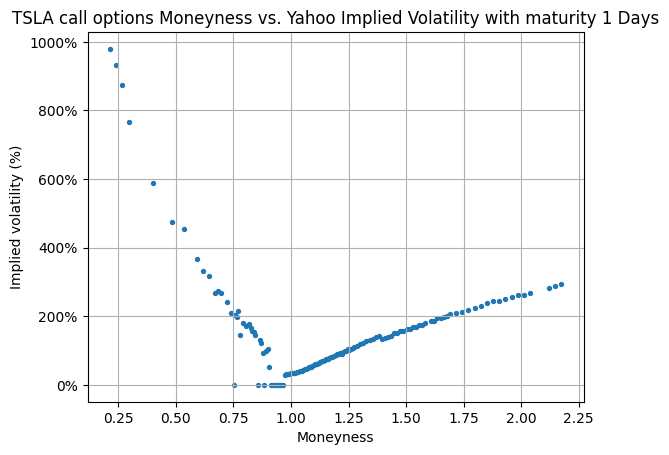

In [103]:
maturity_plot = data_call["time_to_maturity"].value_counts().idxmax()
days = int(maturity_plot*360)
call_plot = data_call[data_call["time_to_maturity"] == maturity_plot]

plt.scatter(call_plot["moneyness"], call_plot["yahoo_implied_vol"], s=8)
plt.ylabel("Implied volatility (%)")
plt.xlabel("Moneyness")
plt.title(f"TSLA call options Moneyness vs. Yahoo Implied Volatility with maturity {days} Days")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

plt.grid(True)
plt.show()

### Implied Volatility for a single maturity

In [104]:
def call_price(risk_free_rate, maturity, K, S, volatility):
    d1 = (np.log(S / K) + (risk_free_rate + 0.5*volatility**2)*maturity) / (volatility*np.sqrt(maturity))
    d2 = d1 - volatility*np.sqrt(maturity)
    return S*norm.cdf(d1) - K*np.exp(-risk_free_rate*maturity)*norm.cdf(d2)

def put_price(risk_free_rate, maturity, K, S, volatility):
    return call_price(risk_free_rate, maturity, K, S, volatility) - S + K*np.exp(-risk_free_rate*maturity)

In [105]:
def implied_volatility_dichotomy(time_to_maturity, risk_free_rate, strike, price, option_price, tol=0.01, max_iter = 50):
    upper = 1000.0 / 100.0
    lower = 10.0 / 100.0

    for _ in range(max_iter):
        price_upper = call_price(risk_free_rate, time_to_maturity, strike, price, upper)
        price_lower = call_price(risk_free_rate, time_to_maturity, strike, price, lower)

        if option_price >= price_upper:
            lower = upper
            upper = 2*upper
        elif option_price <= price_lower:
            upper = lower
            lower = 0.5*lower
        else:
            middle = 0.5*(upper+lower)
            price_middle = call_price(risk_free_rate, time_to_maturity, strike, price, lower)
            if price_middle >= option_price:
                upper = middle
            else:
                lower = middle

        if abs(option_price - 0.5*(price_upper+price_lower)) < tol:
            return (upper+lower)/2

    return (upper+lower)/2

In [106]:
def implied_volatility(time_to_maturity, risk_free_rate, strike, price, option_price, tol=0.01):
    def target(x):
        diff = call_price(risk_free_rate, time_to_maturity, strike, price, np.exp(x)) - option_price
        return diff**2
    res = scipy.optimize.minimize(target, x0=np.exp(50.0/100.0), tol=tol, method="Nelder-Mead")
    return np.exp(res.x)

In [107]:
data_call["implied_vol"] = 0.0
for (k, option) in data_call.iterrows():
    impl_vol = implied_volatility(option["time_to_maturity"], risk_free_rate, option["strike"], price, option["price"], tol=0.005)
    data_call.loc[k, "implied_vol"] = impl_vol

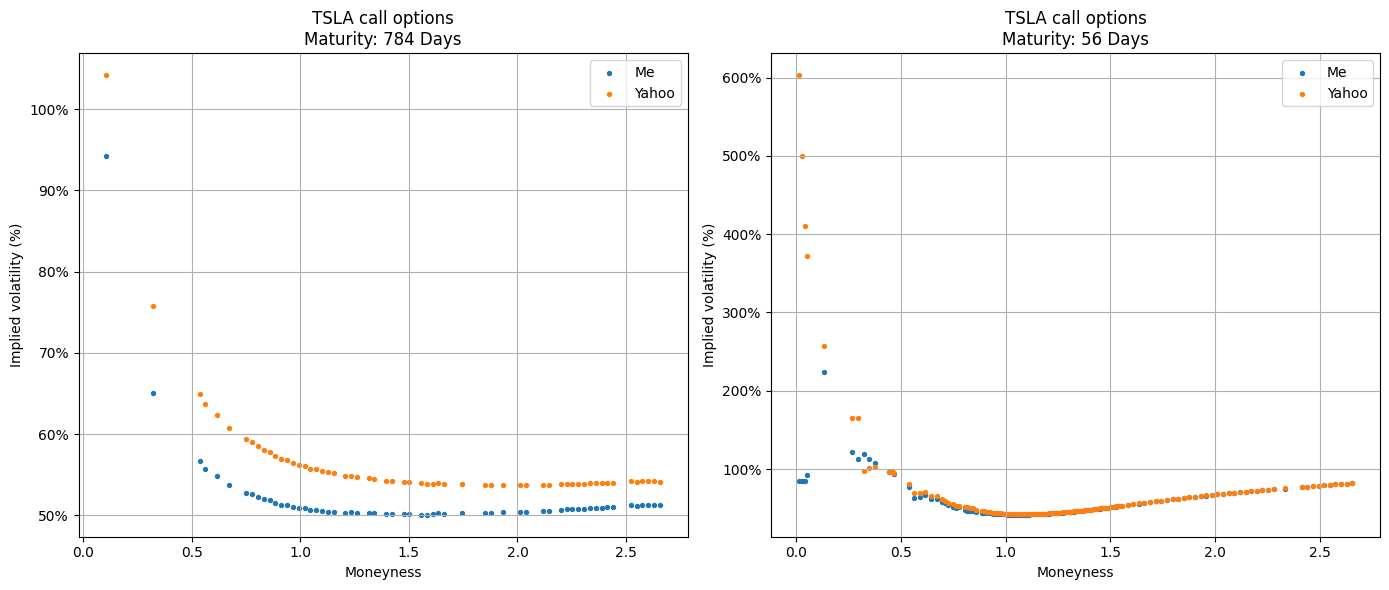

In [108]:
# Get the two most common maturities
maturities = data_call["time_to_maturity"].unique()[[2,3]]
days_list = [int(mat * 360) for mat in maturities]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for the first maturity
maturity_1 = maturities[0]
call_plot_1 = data_call[data_call["time_to_maturity"] == maturity_1]
axes[0].scatter(call_plot_1["moneyness"], call_plot_1["implied_vol"], s=8, label="Me")
axes[0].scatter(call_plot_1["moneyness"], call_plot_1["yahoo_implied_vol"], s=8, label="Yahoo")
axes[0].set_ylabel("Implied volatility (%)")
axes[0].set_xlabel("Moneyness")
axes[0].set_title(f"TSLA call options\nMaturity: {days_list[0]} Days")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
axes[0].legend()
axes[0].grid(True)

# Plot for the second maturity
maturity_2 = maturities[1]
call_plot_2 = data_call[data_call["time_to_maturity"] == maturity_2]
axes[1].scatter(call_plot_2["moneyness"], call_plot_2["implied_vol"], s=8, label="Me")
axes[1].scatter(call_plot_2["moneyness"], call_plot_2["yahoo_implied_vol"], s=8, label="Yahoo")
axes[1].set_ylabel("Implied volatility (%)")
axes[1].set_xlabel("Moneyness")
axes[1].set_title(f"TSLA call options\nMaturity: {days_list[1]} Days")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Interpolation


In [ ]:
# moneyness_grid = np.linspace(start=0.8, stop=1.2, num=50)
# time_grid = np.linspace(start=1.0/360.0, stop=360.0/360.0, num=50)
# 
# # def epanechnikov_kernel(u: np.ndarray):
#     return 0.75*(1-u**2)*(np.abs(u)<=1.0)

# def interpolate_call_price(moneyness, maturity, prices_df, bandwidth_x):
#     implied_vols = prices_df.loc[prices_df["time_to_maturity"] == maturity, "implied_vol"].to_numpy()
#     options_moneyness = prices_df.loc[prices_df["time_to_maturity"] == maturity, "moneyness"].to_numpy()

#     def functional( p: np.ndarray ):
#         return ((
#             implied_vols
#             - p[0] - p[1] * (options_moneyness - moneyness) - p[2] * ( (options_moneyness - moneyness) ** 2 )
#         ) **2 * (1/bandwidth_x) * epanechnikov_kernel((options_moneyness - moneyness)/bandwidth_x)).sum()

#     def interpolation( p: np.ndarray ):
#         return ((
#             p[0] + p[1] * (options_moneyness - moneyness) + p[2] * ( (options_moneyness - moneyness) ** 2 )
#         ) * (1/bandwidth_x) * epanechnikov_kernel((options_moneyness - moneyness)/bandwidth_x)).mean()
    
#     x0 = np.zeros( 3 )
#     res = scipy.optimize.minimize(functional, x0)
#     return interpolation(res.x)

In [110]:
# maturity = data_call["time_to_maturity"].unique()[3]
# test_df = data_call[(data_call["moneyness"] >= 0.8) & (data_call["moneyness"] <= 1.2) & (data_call["time_to_maturity"] == maturity)].copy()
# implied_vol = [interpolate_call_price(K, maturity, test_df, 0.05) for K in moneyness_grid]

## Plot

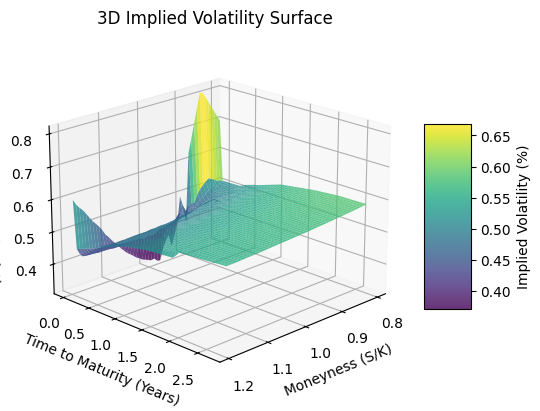

In [115]:
plot_data = data_call[(data_call["moneyness"] >= 0.8) & (data_call["moneyness"] <= 1.2) & (data_call["time_to_maturity"] >= 3/360)].copy()
moneyness = plot_data["moneyness"].values
maturity = plot_data["time_to_maturity"].values
implied_vol = plot_data["yahoo_implied_vol"].values

moneyness_grid = np.linspace(moneyness.min(), moneyness.max(), 50)
maturity_grid = np.linspace(maturity.min(), maturity.max(), 50)
moneyness_mesh, maturity_mesh = np.meshgrid(moneyness_grid, maturity_grid)

vol_grid = griddata(
    (moneyness, maturity),
    implied_vol,
    (moneyness_mesh, maturity_mesh),
    method="linear"
)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    moneyness_mesh,
    maturity_mesh,
    vol_grid,
    cmap="viridis",
    edgecolor="none",
    alpha=0.8
)

ax.set_xlabel("Moneyness (S/K)")
ax.set_ylabel("Time to Maturity (Years)")
ax.set_zlabel("Implied Volatility (%)")
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=4, label="Implied Volatility (%)")

ax.view_init(elev=20, azim=45)

plt.title("3D Implied Volatility Surface")
plt.show()